### K-Nearest Neighbors (KNN) Imputation
Replace missing values based on the values of the k-nearest data points.

Pros:
- Uses patterns from real data, making it more accurate than mean/median imputation.
- Works well when missing values are not random.

Cons:
- Computationally expensive for large datasets.
- May distort relationships if neighbors are not similar.

**When to Use?**
- Data has relationships or correlations across columns (e.g., age may relate to weight or cholesterol).
- When missing data is not missing at random (MNAR).
- When dataset is small to medium-sized with well-defined clusters.

In [13]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer

In [ ]:
# For reproducibility
# np.random.seed(42)

# # Step 1: Generate synthetic patient data
# n = 60
# ages = np.random.normal(loc=50, scale=15, size=n).round(1)  # mean age 50
# weights = np.random.normal(loc=70, scale=10, size=n).round(1)  # weight in kg
# heights = np.random.normal(loc=170, scale=10, size=n).round(1)  # height in cm
# cholesterol = np.random.normal(loc=190, scale=25, size=n).round(1)  # mg/dL

# # Step 2: Introduce ~15% missing values randomly
# def introduce_missing(data, missing_rate=0.15):
#     mask = np.random.choice([True, False], size=len(data), p=[missing_rate, 1 - missing_rate])
#     data[mask] = np.nan
#     return data

# ages = introduce_missing(ages)
# weights = introduce_missing(weights)
# heights = introduce_missing(heights)
# cholesterol = introduce_missing(cholesterol)

# # Step 3: Create DataFrame
# df = pd.DataFrame({
#     'Age': ages,
#     'Weight_kg': weights,
#     'Height_cm': heights,
#     'Cholesterol_Level': cholesterol
# })
# df.to_csv('missing_patient_info_KNN.csv', index=False)

In [2]:

df = pd.read_csv('missing_patient_info_KNN.csv')
print("First 10 rows of dataset with missing values:")
print(df.head(10))

First 10 rows of dataset with missing values:
    Age  Weight_kg  Height_cm  Cholesterol_Level
0  57.5        NaN        NaN              205.6
1   NaN        NaN      160.9              168.6
2   NaN        NaN      184.0              163.2
3  72.8       58.0        NaN              202.1
4  46.5        NaN        NaN              184.4
5  46.5       83.6      191.9              207.9
6  73.7       69.3        NaN              201.8
7  61.5        NaN      164.3                NaN
8  43.0       73.6      171.0              168.8
9  58.1       63.5        NaN              152.1


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                49 non-null     float64
 1   Weight_kg          48 non-null     float64
 2   Height_cm          44 non-null     float64
 3   Cholesterol_Level  54 non-null     float64
dtypes: float64(4)
memory usage: 2.0 KB
None


In [6]:

# Make a copy for imputation
df_knn = df.copy()

# Step 1: Initialize KNNImputer (using 3 neighbors)
imputer = KNNImputer(n_neighbors=3)

In [9]:
# Step 2: Fit and transform

data_knn_imputed = imputer.fit_transform(df_knn)
print(data_knn_imputed)

[[ 57.5         70.96666667 166.46666667 205.6       ]
 [ 37.76666667  63.66666667 160.9        168.6       ]
 [ 49.26666667  62.26666667 184.         163.2       ]
 [ 72.8         58.         182.43333333 202.1       ]
 [ 46.5         71.86666667 174.5        184.4       ]
 [ 46.5         83.6        191.9        207.9       ]
 [ 73.7         69.3        176.13333333 201.8       ]
 [ 61.5         63.96666667 164.3        189.53333333]
 [ 43.          73.6        171.         168.8       ]
 [ 58.1         63.5        173.33333333 152.1       ]
 [ 43.          70.56666667 175.1        178.8       ]
 [ 43.          85.4        170.7        211.4       ]
 [ 53.6         69.6        159.4        195.4       ]
 [ 21.3         85.6        174.7        158.9       ]
 [ 24.1         43.8        160.8        194.3       ]
 [ 41.6         78.2        185.5        199.6       ]
 [ 34.8         70.9        162.2        167.9       ]
 [ 54.7         67.         166.8        193.8       ]
 [ 36.4   

In [11]:
# Step 3: Convert back to DataFrame
df_knn_imputed = pd.DataFrame(data_knn_imputed, columns=df.columns)

# Show after
print("After KNN Imputation:\n", df_knn_imputed)

After KNN Imputation:
           Age  Weight_kg   Height_cm  Cholesterol_Level
0   57.500000  70.966667  166.466667         205.600000
1   37.766667  63.666667  160.900000         168.600000
2   49.266667  62.266667  184.000000         163.200000
3   72.800000  58.000000  182.433333         202.100000
4   46.500000  71.866667  174.500000         184.400000
5   46.500000  83.600000  191.900000         207.900000
6   73.700000  69.300000  176.133333         201.800000
7   61.500000  63.966667  164.300000         189.533333
8   43.000000  73.600000  171.000000         168.800000
9   58.100000  63.500000  173.333333         152.100000
10  43.000000  70.566667  175.100000         178.800000
11  43.000000  85.400000  170.700000         211.400000
12  53.600000  69.600000  159.400000         195.400000
13  21.300000  85.600000  174.700000         158.900000
14  24.100000  43.800000  160.800000         194.300000
15  41.600000  78.200000  185.500000         199.600000
16  34.800000  70.900000 

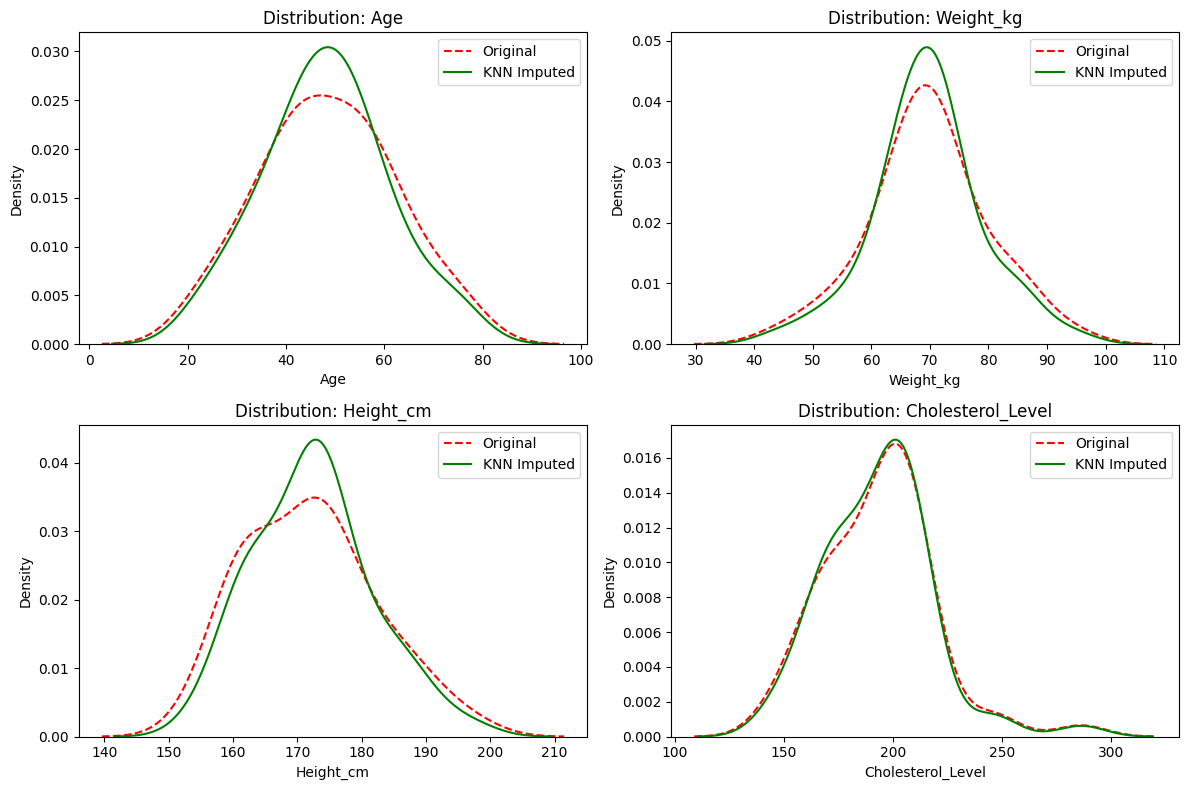

In [14]:
# Plot distribution before and after imputation
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['Age', 'Weight_kg', 'Height_cm', 'Cholesterol_Level']

for i, feature in enumerate(features):
    row, col = i // 2, i % 2 # row and col go from 0 to 1
    ax = axes[row, col]
    sns.kdeplot(df[feature], label='Original', ax=ax, color='red', linestyle="--")
    sns.kdeplot(df_knn_imputed[feature], label='KNN Imputed', ax=ax, color='green')
    ax.set_title(f"Distribution: {feature}")
    ax.legend()

plt.tight_layout()
plt.show()

#### obervation
**Why KNN was Beneficial Here**
- It preserved the original distribution better than mean/median, as you’ll see in the KDE plots.
- Missing values were filled contextually, not blindly. E.g., if a patient had similar age and height to another, KNN used that info to estimate weight or cholesterol.
- Works especially well in **multivariate data** (like medical records).